In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms
import torch.nn as nn
import torchvision.models as models
from torchsummary import summary

from collections import Counter


from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split



%matplotlib inline

# Set default aesthetics for seaborn
sns.set(style="whitegrid")

In [ ]:
#!/bin/bash
!curl -L -o /content/Dataset   https://www.kaggle.com/api/v1/datasets/download/ashery/chexpert

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 10.7G  100 10.7G    0     0  39.0M      0  0:04:40  0:04:40 --:--:-- 40.9M


In [ ]:
!unzip -q "/content/Dataset" -d "/content/CheXpert-v1.0-small"

In [ ]:
chexpert_root = "/content/CheXpert-v1.0-small"

csv_path = os.path.join(chexpert_root, "valid.csv")  # or train.csv

df = pd.read_csv(csv_path)
print(df.shape)
df.head()

(234, 19)


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/valid/patient64541/study1/...,Male,73,Frontal,AP,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CheXpert-v1.0-small/valid/patient64542/study1/...,Male,70,Frontal,PA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,CheXpert-v1.0-small/valid/patient64542/study1/...,Male,70,Lateral,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,CheXpert-v1.0-small/valid/patient64543/study1/...,Male,85,Frontal,AP,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CheXpert-v1.0-small/valid/patient64544/study1/...,Female,42,Frontal,AP,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df = df[df["Frontal/Lateral"] == "Frontal"].reset_index(drop=True)
print("Frontal samples:", len(df))

Frontal samples: 202


In [ ]:
COMMON_LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion",
    "Pneumonia",
    "Pneumothorax"
]

In [ ]:
df = df[["Path"] + COMMON_LABELS]
df.head()

,Path,Atelectasis,Cardiomegaly,Consolidation,Edema,Pleural Effusion,Pneumonia,Pneumothorax
0,CheXpert-v1.0-small/valid/patient64541/study1/...,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,CheXpert-v1.0-small/valid/patient64542/study1/...,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CheXpert-v1.0-small/valid/patient64543/study1/...,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,CheXpert-v1.0-small/valid/patient64544/study1/...,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CheXpert-v1.0-small/valid/patient64545/study1/...,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
df[COMMON_LABELS] = df[COMMON_LABELS].fillna(0)

In [ ]:
df["Path"] = df["Path"].apply(lambda x: os.path.join("/content", x))


In [ ]:
df.head()

,Path,Atelectasis,Cardiomegaly,Consolidation,Edema,Pleural Effusion,Pneumonia,Pneumothorax
0,/content/CheXpert-v1.0-small/valid/patient6454...,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,/content/CheXpert-v1.0-small/valid/patient6454...,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/content/CheXpert-v1.0-small/valid/patient6454...,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,/content/CheXpert-v1.0-small/valid/patient6454...,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/content/CheXpert-v1.0-small/valid/patient6454...,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
for label in COMMON_LABELS:
    positives = (df[label] == 1).sum()
    negatives = (df[label] == 0).sum()
    print(f"{label}: +{positives}, -{negatives}")

Atelectasis: +75, -127
Cardiomegaly: +66, -136
Consolidation: +32, -170
Edema: +42, -160
Pleural Effusion: +64, -138
Pneumonia: +8, -194
Pneumothorax: +7, -195


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
class CheXpertDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["Path"]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        labels = row[COMMON_LABELS].values.astype(np.float32)

        # Create mask for uncertain labels (-1)
        mask = (labels != -1).astype(np.float32)

        # Replace -1 with 0 temporarily
        labels[labels == -1] = 0

        return img, torch.tensor(labels), torch.tensor(mask)

In [ ]:
dataset = CheXpertDataset(df, transform=transform)

dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,  #no shuffle for evaluation
    num_workers=2,
    pin_memory=True
)

In [ ]:
print("Total samples:", len(dataset))

img, labels, mask = dataset[0]
print("Image shape:", img.shape)
print("Labels:", labels)
print("Mask:", mask)

Total samples: 202
Image shape: torch.Size([3, 224, 224])
Labels: tensor([0., 1., 0., 0., 0., 0., 0.])
Mask: tensor([1., 1., 1., 1., 1., 1., 1.])


#Model Building

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class CNNBranch(nn.Module):
    def __init__(self, out_dim=768, pretrained=True, freeze=False):
        super(CNNBranch, self).__init__()

        #Load DenseNet-121
        densenet = models.densenet121(
            weights=models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        )

        dense_feats = list(densenet.features.children())

        # Extract up to denseblock3 (index 8)
        self.features = nn.Sequential(
            *dense_feats[:9]
            )   # includes index 8

        if freeze:
            for p in self.features.parameters():
                p.requires_grad = False

        # After denseblock3:
        # Output shape: (B, 1024, 14, 14)
        in_channels = 1024

        # Project to ViT embedding dimension
        self.proj = nn.Conv2d(in_channels, out_dim, kernel_size=1, bias=False)
        self.ln = nn.LayerNorm(out_dim)

    def forward(self, x):
        # CNN feature map: (B, 1024, 14, 14)
        feat = self.features(x)

        # Project to 768 channels
        feat = self.proj(feat)  # (B, 768, 14, 14)

        # Flatten spatial tokens 14×14 = 196 tokens
        tokens = feat.flatten(2).transpose(1, 2)  # (B, 196, 768)

        # Normalize tokens
        return self.ln(tokens)


In [ ]:
!pip install open_clip_torch transformers pillow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models


from open_clip import create_model_from_pretrained
class BiomedCLIPViTBranch(nn.Module):
    """
    BiomedCLIP ViT branch
    """
    def __init__(self, target_dim=768, freeze=True, dropout=0.1):
        super().__init__()

        print("\n" + "="*70)
        print("Loading BiomedCLIP ViT Branch (Fixed with Projection)")
        print("="*70)


        # Load BiomedCLIP model
        print("\nLoading BiomedCLIP from HuggingFace...")
        self.model, self.preprocess = create_model_from_pretrained(
            'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
        )
        self.model_loaded = "BiomedCLIP"
        print("BiomedCLIP loaded successfully!")

        # Extract vision encoder
        self.vision_model = self.model.visual
        print("Vision encoder extracted")


        if hasattr(self.vision_model, 'output_dim'):
            self.actual_dim = self.vision_model.output_dim
            print(f"    BiomedCLIP output_dim: {self.actual_dim}")
        elif hasattr(self.vision_model, 'embed_dim'):
            self.actual_dim = self.vision_model.embed_dim
            print(f"    BiomedCLIP embed_dim: {self.actual_dim}")
        else:
            # Infer from model structure
            self.actual_dim = 512  # BiomedCLIP default
            print(f"    BiomedCLIP inferred dim: {self.actual_dim}")



        print(f"\nSetting up dimension projection...")
        print(f"    Input dimension: {self.actual_dim}")
        print(f"    Target dimension: {target_dim}")

        if self.actual_dim != target_dim:
            # Create projection layer
            self.proj = nn.Linear(self.actual_dim, target_dim)
            print(f"Projection layer created ({self.actual_dim} -> {target_dim})")
            self.needs_projection = True
        else:
            # No projection needed
            self.proj = nn.Identity()
            print(f"No projection needed (dimensions match)")
            self.needs_projection = False

        self.embed_dim = target_dim  #Output dimension is always target_dim


        if freeze:
            for p in self.vision_model.parameters():
                p.requires_grad = False
            print(f"\n{self.model_loaded} backbone frozen")

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

        print(f"\n{'='*70}")
        print(f"Configuration:")
        print(f"  Model: {self.model_loaded}")
        print(f"  Input Dim: {self.actual_dim}")
        print(f"  Output Dim: {self.embed_dim}")
        print(f"  Projection: {self.needs_projection}")
        print(f"  Frozen: {freeze}")
        print(f"  Dropout: {dropout}")
        print(f"  CLIP Model Type: {type(self.vision_model)}")
        print(f"  CLIP Model: {self.vision_model}")
        print(f"{'='*70}\n")

    def forward(self, x):
            """
            x: (B, 3, H, W)
            returns: (B, embed_dim)  - projected features ready for fusion.
            """
            #extracting vison model of BiomedCLIP
            vision = self.vision_model

            # Vision models accept the image tensor and return image features.
            # Handling a few common possibilities to be robust.
            with torch.no_grad() if not any(p.requires_grad for p in vision.parameters()) else torch.enable_grad():
                # vision(x) returns a (B, D) feature tensor
                try:
                    image_features = vision(x)   # (B,D)
                except Exception:
                    # fallback- call trunk explicitly if it exists
                    if hasattr(vision, "trunk"):
                        image_features = vision.trunk(x)  # trunk typically returns (B, D) or (B, N, D)
                    else:
                        # trying visual.forward
                        image_features = vision.forward(x)


            if isinstance(image_features, (tuple, list)):
                image_features = image_features[0]

            # If (B, N, D) (sequence tokens), pool to get (B, D)
            if image_features.ndim == 3:
                # extracting the [cls] token
                image_features = image_features[:, 0, :]

            # Project to target dim if needed
            image_features = self.proj(image_features)   # (B, target_dim)
            image_features = self.dropout(image_features)

            return image_features  # (B, target_dim)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DynamicFusionGate(nn.Module):
    def __init__(self, embed_dim=768, hidden_dim=256, reduction="softmax",dropout=0.2, temperature=2.0):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim*2, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)
        )
        self.reduction = reduction
        self.temperature = temperature

        # This gives balanced starting point, but allows learning
        nn.init.normal_(self.mlp[-1].weight, mean=0, std=0.01)
        nn.init.constant_(self.mlp[-1].bias, 0)

    def forward(self, cnn_tokens, vit_tokens):
        # cnn_tokens: (B,196,768), vit_tokens: (B,768)
        # Expand vit_tokens to match sequence length
        B, N, D = cnn_tokens.size()
        vit_expanded = vit_tokens.unsqueeze(1).expand(B, N, D)  # (B,N,768)

        fused_input = torch.cat([cnn_tokens, vit_expanded], dim=-1)  # (B,N,1536)

        weights = self.mlp(fused_input)                              # (B,N,2)
        if self.reduction=="softmax":
            weights = torch.softmax(weights / self.temperature, dim=-1)
        else:
            weights = torch.sigmoid(weights)

        w_cnn = weights[...,0].unsqueeze(-1)  # (B,N,1)
        w_vit = weights[...,1].unsqueeze(-1)
        fused = w_cnn*cnn_tokens + w_vit*vit_expanded                  # (B,N,768)

        return fused, (w_cnn, w_vit)

In [ ]:
class MultiLabelClassifier(nn.Module):
    def __init__(self, embed_dim=768, num_classes=14, dropout=0.2):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, tokens):
        # tokens: (B,N,768)
        tokens = tokens.transpose(1,2)  # (B,768,N)
        pooled = self.pool(tokens).squeeze(-1)  # (B,768)
        out = self.dropout(pooled)
        logits = self.fc(out)  # (B,num_classes)

        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CheXDFuseNet(nn.Module):
    def __init__(self, num_classes=14, embed_dim=768, vit_model="vit_base_patch16_224"):
        super().__init__()
        self.cnn_branch = CNNBranch(out_dim=embed_dim, freeze=False)
        self.vit_branch = BiomedCLIPViTBranch(freeze=False)
        self.dfg = DynamicFusionGate(embed_dim=embed_dim, hidden_dim=256)
        self.head = MultiLabelClassifier(embed_dim=embed_dim, num_classes=num_classes)

    def forward(self, x, return_weights=True):
        f_cnn = self.cnn_branch(x)  # (B,196,768)
        f_vit = self.vit_branch(x)  # (B,768)
        fused, (w_cnn, w_vit) = self.dfg(f_cnn, f_vit)  # (B,196,768)

        logits = self.head(fused)                     # (B,14)
        if return_weights:
            return logits, (w_cnn, w_vit)
        return logits

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model = CheXDFuseNet(num_classes=15).to(device)


Loading BiomedCLIP ViT Branch (Fixed with Projection)

Loading BiomedCLIP from HuggingFace...
BiomedCLIP loaded successfully!
Vision encoder extracted
    BiomedCLIP inferred dim: 512

Setting up dimension projection...
    Input dimension: 512
    Target dimension: 768
Projection layer created (512 → 768)

Configuration:
  Model: BiomedCLIP
  Input Dim: 512
  Output Dim: 768
  Projection: True
  Frozen: False
  Dropout: 0.1
  CLIP Model Type: <class 'open_clip.timm_model.TimmModel'>
  CLIP Model: TimmModel(
  (trunk): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          

In [ ]:
checkpoint = torch.load("/content/drive/MyDrive/checkpoints/Model-23/chex_dfusenet_model_deploy.pt", map_location="cpu", weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()



CheXDFuseNet(
  (cnn_branch): CNNBranch(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, tr

In [ ]:
nih_classes = checkpoint["class_names"]
nih_thresholds = checkpoint["optimal_thresholds"]

In [ ]:

print(nih_classes)

['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [ ]:


chexpert_to_nih_map = {
    "Atelectasis": "Atelectasis",
    "Cardiomegaly": "Cardiomegaly",
    "Consolidation": "Consolidation",
    "Edema": "Edema",
    "Pleural Effusion": "Effusion",
    "Pneumonia": "Pneumonia",
    "Pneumothorax": "Pneumothorax"
}

common_indices = []
chexpert_class_names = []

for chex_label, nih_label in chexpert_to_nih_map.items():
    if nih_label in nih_classes:
        idx = nih_classes.index(nih_label)
        common_indices.append(idx)
        chexpert_class_names.append(chex_label)

chexpert_thresholds = np.array(nih_thresholds)[common_indices]

In [ ]:
print(chexpert_class_names)
print(chexpert_thresholds)

['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion', 'Pneumonia', 'Pneumothorax']
[0.54 0.51 0.45 0.47 0.57 0.35 0.54]


In [ ]:
print(nih_classes)
print(nih_thresholds)

['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
[0.54, 0.51, 0.45, 0.47, 0.57, 0.52, 0.46, 0.42, 0.52, 0.57, 0.57, 0.45, 0.44, 0.35, 0.54]


In [ ]:
def plot_masked_roc_curves(y_true, y_prob, y_mask, class_names):

    plt.figure(figsize=(16, 12))

    for i in range(len(class_names)):

        valid_idx = y_mask[:, i] == 1

        y_true_i = y_true[valid_idx, i]
        y_prob_i = y_prob[valid_idx, i]

        if len(np.unique(y_true_i)) > 1:
            fpr, tpr, _ = roc_curve(y_true_i, y_prob_i)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2,
                     label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('CheXpert ROC Curves ')
    plt.legend(loc="lower right", fontsize='small')
    plt.grid(True)
    plt.show()

In [ ]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, hamming_loss, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
def evaluate_chexpert_generalization(
        model,
        test_loader,
        device,
        class_names,
        thresholds
):
    model.eval()

    all_logits = []
    all_targets = []
    all_masks = []

    with torch.no_grad():
        for images, targets, masks in test_loader:
            images = images.to(device)

            model_output = model(images)
            logits = model_output[0]

            all_logits.append(logits.cpu())
            all_targets.append(targets.cpu())
            all_masks.append(masks.cpu())

    y_prob_full = torch.sigmoid(torch.cat(all_logits)).numpy()
    y_true = torch.cat(all_targets).numpy()
    y_mask = torch.cat(all_masks).numpy()


    # Slice only 7 overlapping classes
    y_prob = y_prob_full[:, common_indices]
    thresholds = np.array(thresholds)
    y_pred = (y_prob > thresholds).astype(int)


    # Masked Metric Computation
    aurocs = []
    f1s = []

    for i in range(len(class_names)):

        valid_idx = y_mask[:, i] == 1

        y_true_i = y_true[valid_idx, i]
        y_prob_i = y_prob[valid_idx, i]
        y_pred_i = y_pred[valid_idx, i]

        if len(np.unique(y_true_i)) > 1:
            aurocs.append(roc_auc_score(y_true_i, y_prob_i))
            f1s.append(f1_score(y_true_i, y_pred_i, zero_division=0))
        else:
            aurocs.append(np.nan)
            f1s.append(np.nan)

    macro_auc = np.nanmean(aurocs)
    macro_f1 = np.nanmean(f1s)

    # Masked Hamming Loss
    valid_entries = y_mask == 1
    total_valid = np.sum(valid_entries)

    ham_loss = np.sum((y_pred != y_true) * valid_entries) / total_valid


    # Print Results
    print("\nCheXpert Dataset External Validation Results")
    print("------------------------------------------------")
    for label, auc_val, f1_val in zip(class_names, aurocs, f1s):
        print(f"{label:20s} | AUROC: {auc_val:.4f} | F1: {f1_val:.4f}")

    print("------------------------------------------------")
    print(f"Macro AUROC: {macro_auc:.4f}")
    print(f"Macro F1:    {macro_f1:.4f}")
    print(f"Hamming Loss: {ham_loss:.4f}")

    # Plot masked ROC curves
    plot_masked_roc_curves(y_true, y_prob, y_mask, class_names)

    return {
        "macro_auc": macro_auc,
        "macro_f1": macro_f1,
        "hamming_loss": ham_loss
    }


CheXpert Dataset External Validation Results
------------------------------------------------
Atelectasis          | AUROC: 0.7738 | F1: 0.3368
Cardiomegaly         | AUROC: 0.8019 | F1: 0.0870
Consolidation        | AUROC: 0.8520 | F1: 0.4151
Edema                | AUROC: 0.7926 | F1: 0.0909
Pleural Effusion     | AUROC: 0.8728 | F1: 0.4773
Pneumonia            | AUROC: 0.6881 | F1: 0.1176
Pneumothorax         | AUROC: 0.6923 | F1: 0.1000
------------------------------------------------
Macro AUROC: 0.7819
Macro F1:    0.2321
Hamming Loss: 0.1952


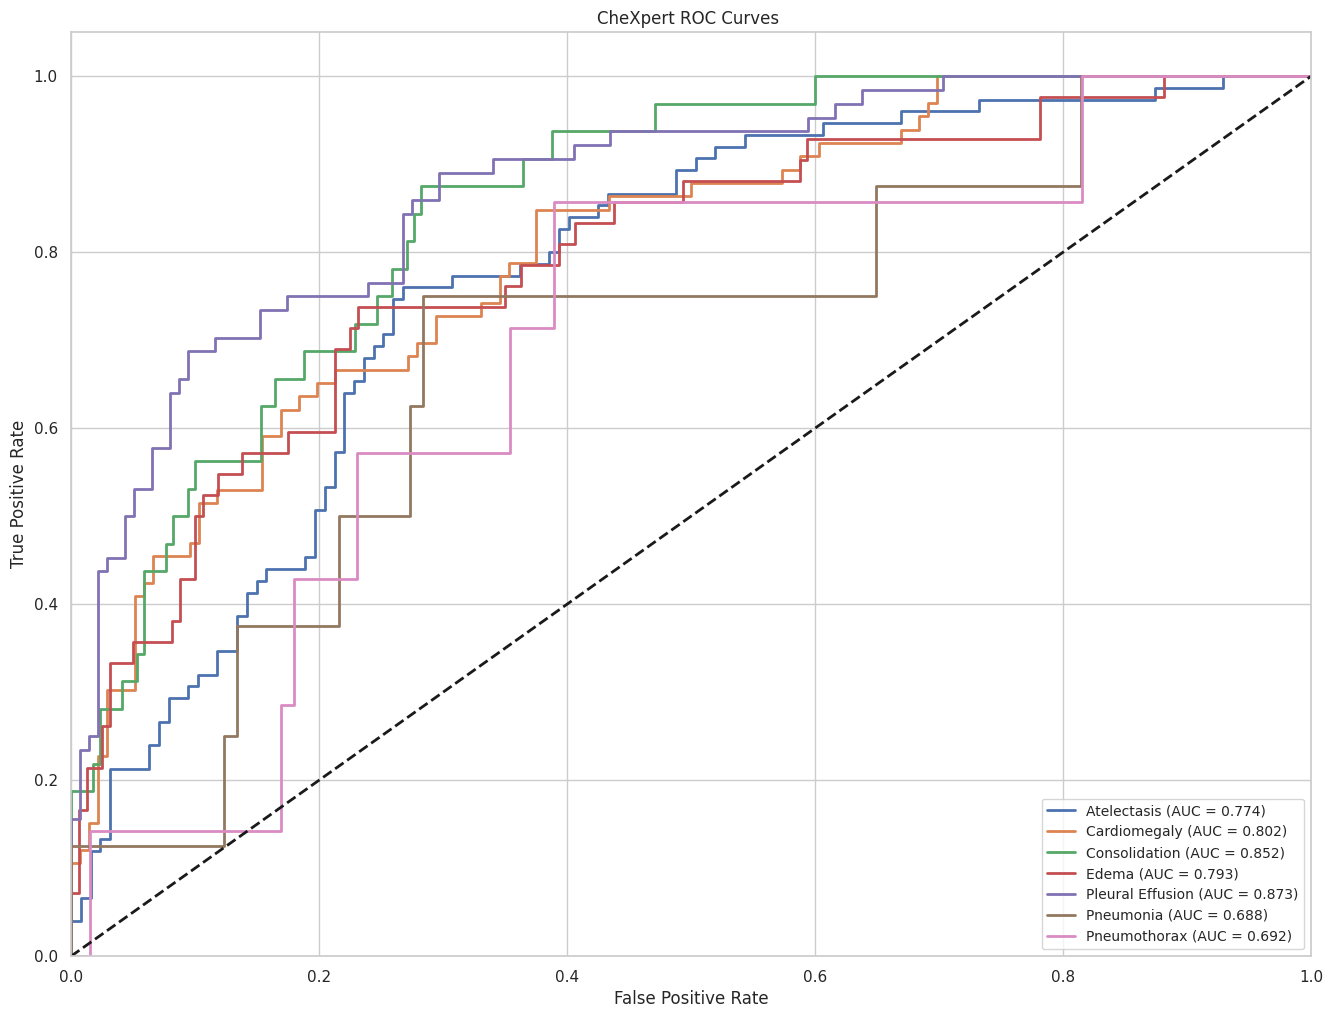

In [ ]:
results = evaluate_chexpert_generalization(
    model=model,
    test_loader=dataloader,
    device=device,
    class_names=chexpert_class_names,
    thresholds=chexpert_thresholds
)